# 5. Using PGD

**PGD**: $x_{k+1} = \pi_D(x_k - \gamma_k \nabla f(x_k))$


**NUMERICAL VALUES OF CONSTANTS FROM PROBLEM 2)**
* $L = \sqrt{72 + 12e^2 + e^4} \approx 14.67$
* $\alpha = \frac{4 + e^{-2} - \sqrt{4 + e^{-4}}}{2} \approx 1.065$
* $\beta = \frac{4 + e^2 + \sqrt{4 + e^4}}{2} \approx 9.52$

**3 DIFFERENT LRs FROM THEOREM 3.3**
* $\gamma^{(1)} = \frac{||x_1 - x^*||}{L\sqrt{T}}$      (for L-Lipschitz)
* $\gamma^{(2)} = \frac{1}{\beta}$                      (for ${\beta}$-smooth & strongly convex)
* $\gamma_k^{(3)} = \frac{2}{\alpha(k+1)}$              (for ${\alpha}$-strongly convex & L-Lipschitz)


initial point x1 = (−1, 1)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Constants and functions

In [2]:
e = np.exp(1)
L = np.sqrt(72 + 12*e**2 + e**4)         # ~14.67
alpha = (4 + e**(-2) - np.sqrt(4 + e**(-4))) / 2  # ~1.065
beta = (4 + e**2 + np.sqrt(4 + e**4)) / 2         # ~9.52

In [3]:
def f(p):
    """The objective function f(x,y) = x^2 + e^x + y^2 - xy"""
    x, y = p[0], p[1]
    return x**2 + np.exp(x) + y**2 - x*y

def grad_f(p):
    """The gradient of f"""
    x, y = p[0], p[1]
    return np.array([2*x + np.exp(x) - y, 2*y - x])

### 2. Projection functions (from problem 3)

In [4]:
def proj_disc(p):
    """Project onto x^2 + y^2 <= 1.5"""
    norm = np.linalg.norm(p)
    max_radius = np.sqrt(1.5)
    if norm <= max_radius:
        return p
    return p * (max_radius / norm)

def proj_square(p):
    """Project onto [-1, 1] x [-1, 1]"""
    return np.clip(p, -1.0, 1.0)

def proj_triangle(p):
    """Project onto the triangle"""
    x, y = p[0], p[1]
    if x >= -1 and y >= -1 and x + y <= 0.5:
        return p
    elif x < -1 and y < -1:
        return np.array([-1.0, -1.0])
    elif -1 <= x <= 1.5 and y < -1:
        return np.array([x, -1.0])
    elif x < -1 and -1 <= y <= 1.5:
        return np.array([-1.0, y])
    elif x - y > 2.5 and y < x - 2.5: # Bottom right corner zone
        return np.array([1.5, -1.0])
    elif y - x > 2.5 and y > x + 2.5: # Top left corner zone
        return np.array([-1.0, 1.5])
    else: # Hypotenuse zone
        return np.array([(x - y + 0.5)/2, (y - x + 0.5)/2])

### 3. PGD

In [5]:
def pgd(init_p, proj_func, lr_func, T=10):
    """
    Runs PGD for T steps.Returns a list of function values at each step to track progress.
    """
    p = np.array(init_p, dtype=float)
    f_history = [f(p)] # Track initial value
    
    for k in range(1, T + 1):
        gradient = grad_f(p)
        lr = lr_func(k) # Fetch learning rate for current step
        step = p - lr * gradient
        p = proj_func(step) # Project back to domain
        f_history.append(f(p))
        
    return f_history

### 4. Running 9 combinations

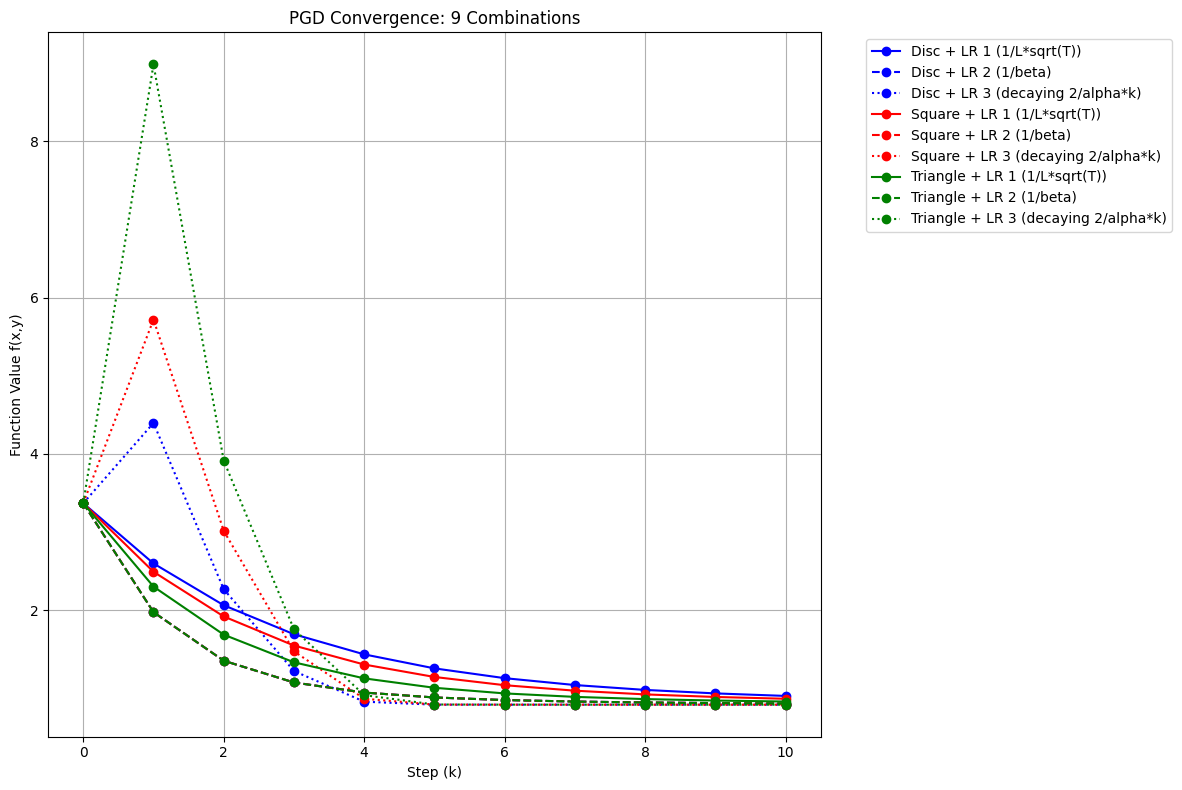

Domain          | Learning Rate Strategy         | Final f(x,y) after 10 steps
---------------------------------------------------------------------------
Disc            | LR 1 (1/L*sqrt(T))             | 0.901610
Disc            | LR 2 (1/beta)                  | 0.804358
Disc            | LR 3 (decaying 2/alpha*k)      | 0.789181
Square          | LR 1 (1/L*sqrt(T))             | 0.865267
Square          | LR 2 (1/beta)                  | 0.804358
Square          | LR 3 (decaying 2/alpha*k)      | 0.789221
Triangle        | LR 1 (1/L*sqrt(T))             | 0.829604
Triangle        | LR 2 (1/beta)                  | 0.804358
Triangle        | LR 3 (decaying 2/alpha*k)      | 0.789268


In [6]:
T = 10
x1 = [-1.0, 1.0]

# Diameters (R) of the domains for LR 1
R_disc = 2 * np.sqrt(1.5)
R_square = 2 * np.sqrt(2)
R_triangle = np.sqrt(2.5**2 + 2.5**2)

domains = {
    "Disc": (proj_disc, R_disc),
    "Square": (proj_square, R_square),
    "Triangle": (proj_triangle, R_triangle)
}

# Setup the plot
plt.figure(figsize=(12, 8))
colors = {"Disc": "blue", "Square": "red", "Triangle": "green"}
line_styles = ["-", "--", ":"]
lr_names = ["LR 1 (1/L*sqrt(T))", "LR 2 (1/beta)", "LR 3 (decaying 2/alpha*k)"]

results_summary = []

for domain_name, (proj_func, R) in domains.items():
    
    # Define the 3 learning rate functions for this specific domain
    lr_funcs = [
        lambda k, R=R: R / (L * np.sqrt(T)), # LR 1: Constant, uses R
        lambda k: 1 / beta,                  # LR 2: Constant
        lambda k: 2 / (alpha * (k + 1))      # LR 3: Decaying
    ]
    
    for i, lr_func in enumerate(lr_funcs):
        # Run PGD
        history = pgd(x1, proj_func, lr_func, T)
        
        # Plotting
        plt.plot(range(T + 1), history, 
                 color=colors[domain_name], 
                 linestyle=line_styles[i], 
                 marker='o',
                 label=f"{domain_name} + {lr_names[i]}")
        
        # Save final result for reporting
        results_summary.append({
            "Domain": domain_name,
            "LR": lr_names[i],
            "Final_f": history[-1]
        })

plt.title("PGD Convergence: 9 Combinations")
plt.xlabel("Step (k)")
plt.ylabel("Function Value f(x,y)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"{'Domain':<15} | {'Learning Rate Strategy':<30} | {'Final f(x,y) after 10 steps'}")
print("-" * 75)
for res in results_summary:
    print(f"{res['Domain']:<15} | {res['LR']:<30} | {res['Final_f']:.6f}")

**25 steps**

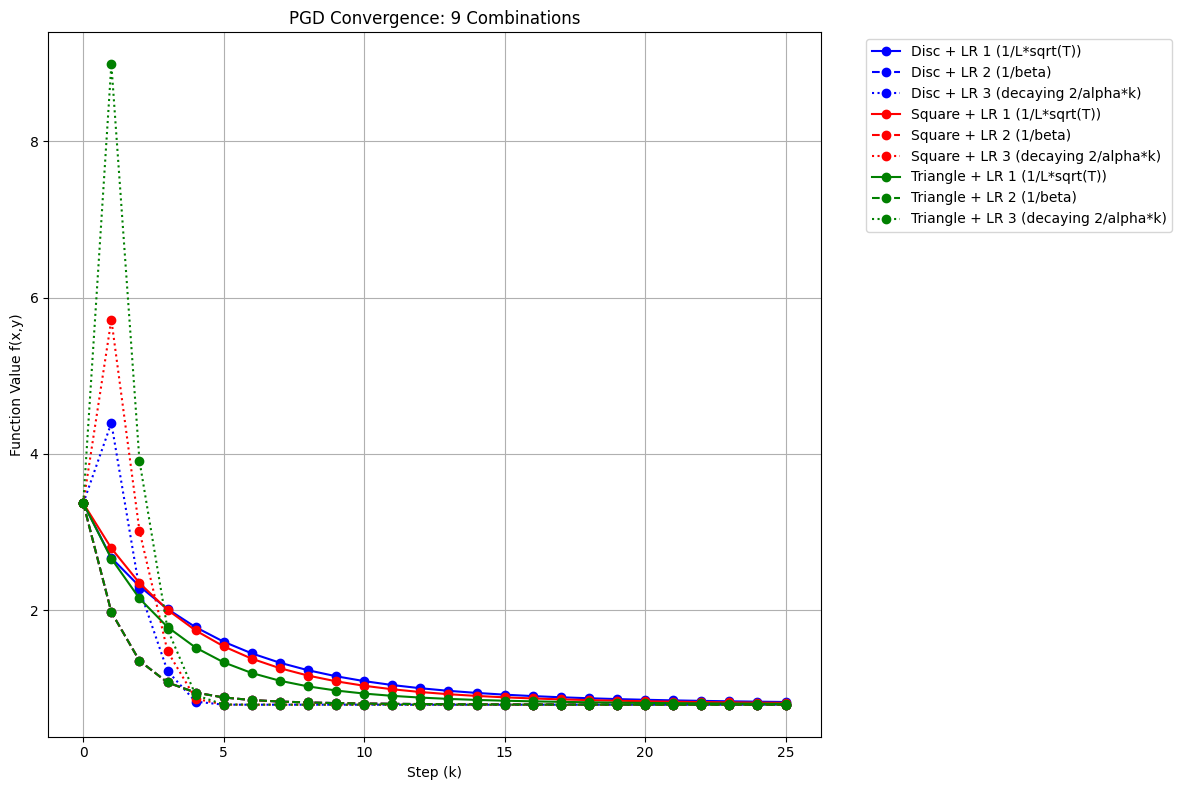

Domain          | Learning Rate Strategy         | Final f(x,y) after 25 steps
---------------------------------------------------------------------------
Disc            | LR 1 (1/L*sqrt(T))             | 0.823901
Disc            | LR 2 (1/beta)                  | 0.789373
Disc            | LR 3 (decaying 2/alpha*k)      | 0.789177
Square          | LR 1 (1/L*sqrt(T))             | 0.812704
Square          | LR 2 (1/beta)                  | 0.789373
Square          | LR 3 (decaying 2/alpha*k)      | 0.789178
Triangle        | LR 1 (1/L*sqrt(T))             | 0.800585
Triangle        | LR 2 (1/beta)                  | 0.789373
Triangle        | LR 3 (decaying 2/alpha*k)      | 0.789178


In [7]:
T = 25
x1 = [-1.0, 1.0]

# Diameters (R) of the domains for LR 1
R_disc = 2 * np.sqrt(1.5)
R_square = 2 * np.sqrt(2)
R_triangle = np.sqrt(2.5**2 + 2.5**2)

domains = {
    "Disc": (proj_disc, R_disc),
    "Square": (proj_square, R_square),
    "Triangle": (proj_triangle, R_triangle)
}

# Setup the plot
plt.figure(figsize=(12, 8))
colors = {"Disc": "blue", "Square": "red", "Triangle": "green"}
line_styles = ["-", "--", ":"]
lr_names = ["LR 1 (1/L*sqrt(T))", "LR 2 (1/beta)", "LR 3 (decaying 2/alpha*k)"]

results_summary = []

for domain_name, (proj_func, R) in domains.items():
    
    # Define the 3 learning rate functions for this specific domain
    lr_funcs = [
        lambda k, R=R: R / (L * np.sqrt(T)), # LR 1: Constant, uses R
        lambda k: 1 / beta,                  # LR 2: Constant
        lambda k: 2 / (alpha * (k + 1))      # LR 3: Decaying
    ]
    
    for i, lr_func in enumerate(lr_funcs):
        # Run PGD
        history = pgd(x1, proj_func, lr_func, T)
        
        # Plotting
        plt.plot(range(T + 1), history, 
                 color=colors[domain_name], 
                 linestyle=line_styles[i], 
                 marker='o',
                 label=f"{domain_name} + {lr_names[i]}")
        
        # Save final result for reporting
        results_summary.append({
            "Domain": domain_name,
            "LR": lr_names[i],
            "Final_f": history[-1]
        })

plt.title("PGD Convergence: 9 Combinations")
plt.xlabel("Step (k)")
plt.ylabel("Function Value f(x,y)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"{'Domain':<15} | {'Learning Rate Strategy':<30} | {'Final f(x,y) after 25 steps'}")
print("-" * 75)
for res in results_summary:
    print(f"{res['Domain']:<15} | {res['LR']:<30} | {res['Final_f']:.6f}")